# Exploring the ISMIP6 Icechunk Store

This notebook explores the three store types (combined, state, flux) and demonstrates how to compare variables across models and experiments.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Numcodecs codecs are not in the Zarr version 3')

import icechunk
import xarray as xr
import matplotlib.pyplot as plt
import zarr

## Connect to the store

In [2]:
SOURCE_BUCKET = "s3://us-west-2.opendata.source.coop/englacial/ismip6"

storage = icechunk.s3_storage(
    bucket="us-west-2.opendata.source.coop",
    prefix="englacial/ismip6/icechunk-ais",
    region="us-west-2",
    anonymous=True,
)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        SOURCE_BUCKET + "/",
        store=icechunk.s3_store(region="us-west-2", anonymous=True),
    )
)
credentials = icechunk.containers_credentials({SOURCE_BUCKET + "/": None})

repo = icechunk.Repository.open(
    storage=storage,
    config=config,
    authorize_virtual_chunk_access=credentials,
)
session = repo.readonly_session(branch="main")
root = zarr.open(session.store, mode='r')

## Explore the three store types

In [3]:
# Top-level groups
for group_name in sorted(root.keys()):
    group = root[group_name]
    n_models = len(list(group.keys()))
    print(f"{group_name}/ ({n_models} models)")

combined/ (17 models)
flux/ (17 models)
state/ (17 models)


In [4]:
# List experiments for a model in each store type
model = "AWI_PISM1"
for store_type in ["combined", "state", "flux"]:
    try:
        exps = sorted(root[store_type][model].keys())
        print(f"{store_type}/{model}: {len(exps)} experiments")
        print(f"  {exps[:5]}{'...' if len(exps) > 5 else ''}")
    except KeyError:
        print(f"{store_type}/{model}: not found")

combined/AWI_PISM1: 33 experiments
  ['ctrl_proj_std', 'exp01', 'exp02', 'exp03', 'exp04']...
state/AWI_PISM1: 33 experiments
  ['ctrl_proj_std', 'exp01', 'exp02', 'exp03', 'exp04']...
flux/AWI_PISM1: 33 experiments
  ['ctrl_proj_std', 'exp01', 'exp02', 'exp03', 'exp04']...


## Compare combined vs state/flux

The combined store merges all variables and bins time to annual resolution.
The state and flux stores keep native time resolution but only include their respective variable types.

In [5]:
# Open the same model/experiment from each store type
model, exp = "AWI_PISM1", "exp05"

for store_type in ["combined", "state", "flux"]:
    group_path = f"{store_type}/{model}/{exp}"
    ds = xr.open_zarr(session.store, group=group_path, consolidated=False)
    print(f"\n{group_path}:")
    print(f"  Variables: {sorted(ds.data_vars)}")
    if 'time' in ds:
        print(f"  Time: {ds.time.values[0]} to {ds.time.values[-1]} ({len(ds.time)} steps)")


combined/AWI_PISM1/exp05:
  Variables: ['acabf', 'base', 'dlithkdt', 'hfgeoubed', 'libmassbffl', 'libmassbfgr', 'licalvf', 'lifmassbf', 'ligroundf', 'litempbotfl', 'litempbotgr', 'litemptop', 'lithk', 'orog', 'sftflf', 'sftgif', 'sftgrf', 'strbasemag', 'tendligroundf', 'time_bnds', 'topg', 'xvelbase', 'xvelmean', 'xvelsurf', 'yvelbase', 'yvelmean', 'yvelsurf', 'zvelbase', 'zvelsurf']
  Time: 2015-01-01T00:00:00.000000000 to 2101-01-01T00:00:00.000000000 (87 steps)

state/AWI_PISM1/exp05:
  Variables: ['base', 'litempbotfl', 'litempbotgr', 'litemptop', 'lithk', 'orog', 'sftflf', 'sftgif', 'sftgrf', 'strbasemag', 'time_bnds', 'topg', 'xvelbase', 'xvelmean', 'xvelsurf', 'yvelbase', 'yvelmean', 'yvelsurf', 'zvelbase', 'zvelsurf']
  Time: 2016-01-01T00:00:00.000000000 to 2101-01-01T00:00:00.000000000 (86 steps)

flux/AWI_PISM1/exp05:
  Variables: ['acabf', 'dlithkdt', 'hfgeoubed', 'libmassbffl', 'libmassbfgr', 'licalvf', 'lifmassbf', 'ligroundf', 'tendligroundf', 'time_bnds']
  Time: 2015-

## Compare a variable across models

In the combined store, flux and state variables are merged onto a union time axis
with time binned to Jan 1 of each year. Because flux files can start a year earlier
than state files, the first timestep (`time=0`) may be all-NaN for state variables
like `lithk`. We use `time=1` below to select a timestep where all variables have data.

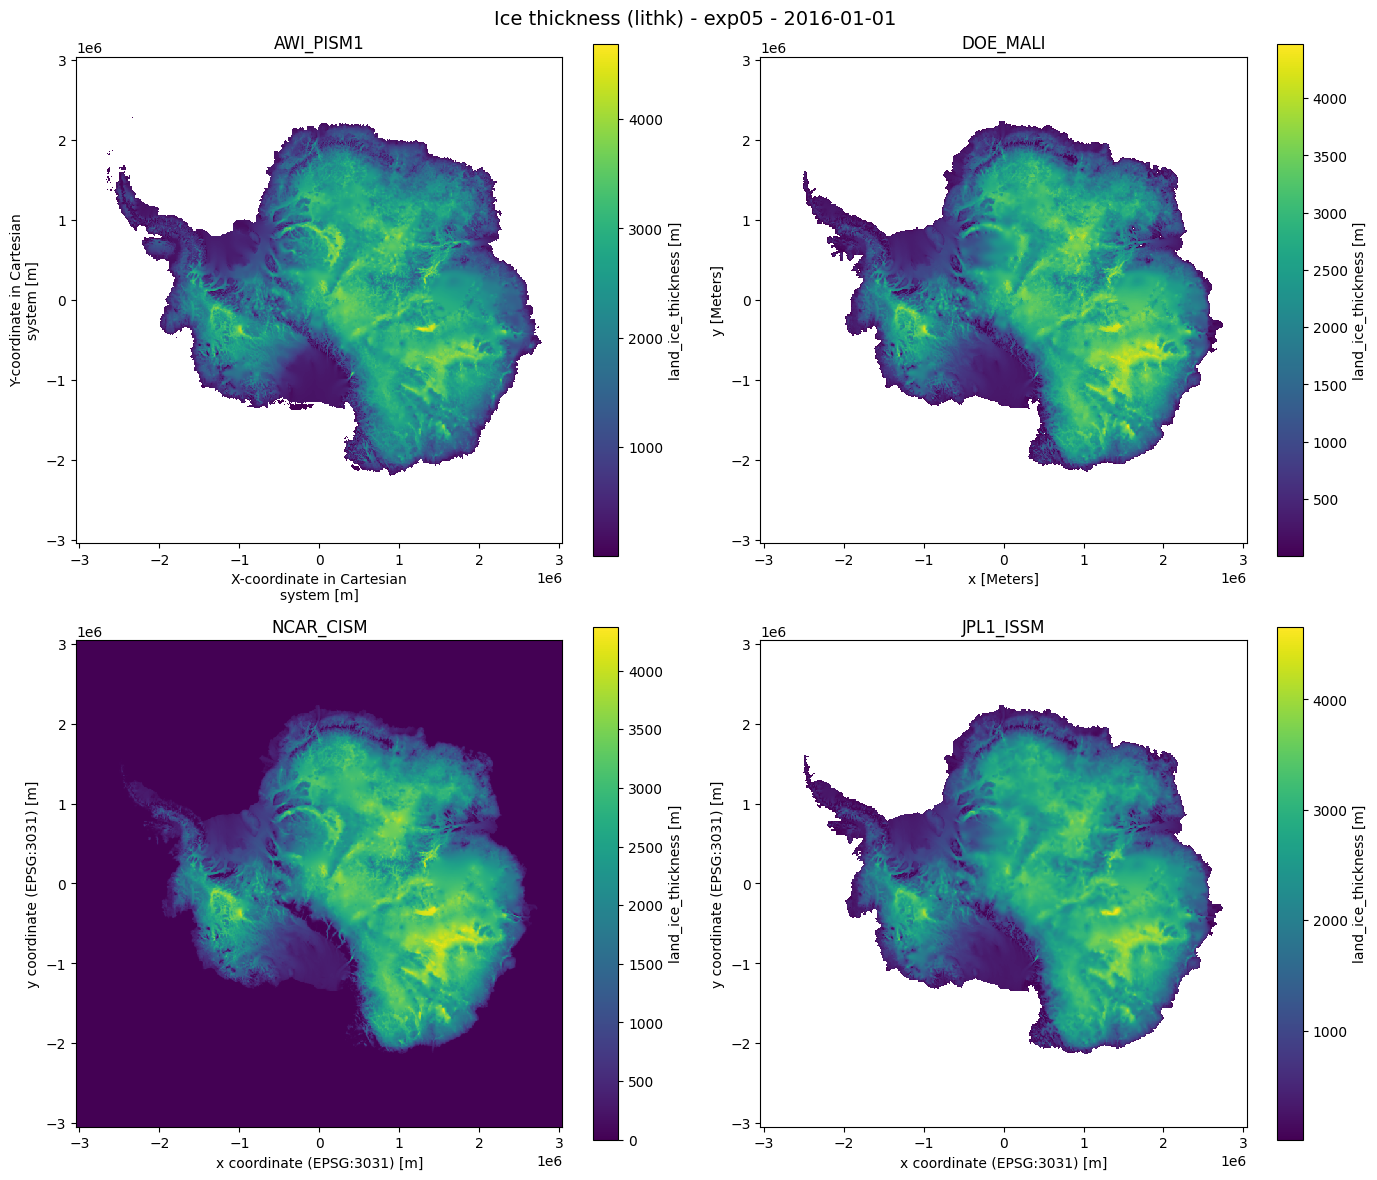

In [6]:
# Compare ice thickness (lithk) across 4 models for exp05
models = ["AWI_PISM1", "DOE_MALI", "NCAR_CISM", "JPL1_ISSM"]
exp = "exp05"

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, model in zip(axes.flat, models):
    ds = xr.open_zarr(session.store, group=f"combined/{model}/{exp}", consolidated=False)
    ds['lithk'].isel(time=1).plot(ax=ax, cmap='viridis', add_colorbar=True)
    ax.set_aspect('equal')
    ax.set_title(f"{model}")

fig.suptitle(f"Ice thickness (lithk) - {exp} - {str(ds.time.values[1])[:10]}", fontsize=14)
plt.tight_layout()

## Check ignore_value annotations

The ingest pipeline annotates arrays with `ignore_value` attributes where sentinel values (e.g. 0.0 in ocean regions) were detected.

In [7]:
# Check which variables have ignore_value annotations
group = root['combined/AWI_PISM1/exp05']
for var_name in sorted(group.keys()):
    arr = group[var_name]
    if 'ignore_value' in arr.attrs:
        attrs = arr.attrs
        print(f"  {var_name}: ignore_value={attrs['ignore_value']}", end="")
        if 'valid_min' in attrs:
            print(f", valid_range=[{attrs['valid_min']:.4g}, {attrs['valid_max']:.4g}]", end="")
        print()

  acabf: ignore_value=1.0000000200408773e+20, valid_range=[-3.446e-06, 0.0001594]
  dlithkdt: ignore_value=1.0000000200408773e+20, valid_range=[-1.783e-06, 1.913e-06]
  hfgeoubed: ignore_value=1.0000000200408773e+20, valid_range=[-0.4163, 0.5527]
  libmassbffl: ignore_value=1.0000000200408773e+20, valid_range=[-0.0007911, 1.134e-06]
  libmassbfgr: ignore_value=1.0000000200408773e+20, valid_range=[-0.0001374, 5.311e-06]
  licalvf: ignore_value=1.0000000200408773e+20
  lifmassbf: ignore_value=1.0000000200408773e+20, valid_range=[-0.001273, 0]
  ligroundf: ignore_value=1.0000000200408773e+20, valid_range=[-0.006733, 0]
